# WESAD Analysis

In [1]:
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import find_peaks, welch
from scipy.interpolate import interp1d

## Load and Summarize Data

In [2]:
def load_wesad_subject(pkl_path: str):
    """Return dict with 'signal', 'label', plus any metadata present."""
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')  # WESAD often needs latin1
    # Normalize a few expected top-level keys if available
    out = {'raw': data}
    # Try common patterns
    for k in ['signal', 'signals', 'data']:
        if k in data:
            out['signal'] = data[k]
            break
    if 'label' in data:
        out['label'] = data['label']
    elif 'labels' in data:
        out['label'] = data['labels']
    return out

def summarize_structure(s):
    print("Top-level keys:", list(s['raw'].keys()))
    sig = s.get('signal', {})
    print("Signal namespaces:", list(sig.keys()))
    for ns, v in sig.items():
        if isinstance(v, dict):
            print(f"  [{ns}] channels:", list(v.keys()))
            for ch, arr in v.items():
                try:
                    print(f"    - {ch}: shape={np.array(arr).shape}, dtype={np.array(arr).dtype}")
                except Exception:
                    print(f"    - {ch}: (non-array)")
    if 'label' in s:
        lab = np.array(s['label']).squeeze()
        print("Labels shape:", lab.shape, "| unique:", np.unique(lab))

In [10]:
path_to_pkl = '../../roeh-health/data/WESAD/per_subject/S7/S7.pkl'
S = load_wesad_subject(path_to_pkl)
summarize_structure(S)

Top-level keys: ['signal', 'label', 'subject']
Signal namespaces: ['chest', 'wrist']
  [chest] channels: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
    - ACC: shape=(3666600, 3), dtype=float64
    - ECG: shape=(3666600, 1), dtype=float64
    - EMG: shape=(3666600, 1), dtype=float64
    - EDA: shape=(3666600, 1), dtype=float64
    - Temp: shape=(3666600, 1), dtype=float32
    - Resp: shape=(3666600, 1), dtype=float64
  [wrist] channels: ['ACC', 'BVP', 'EDA', 'TEMP']
    - ACC: shape=(167616, 3), dtype=float64
    - BVP: shape=(335232, 1), dtype=float64
    - EDA: shape=(20952, 1), dtype=float64
    - TEMP: shape=(20952, 1), dtype=float64
Labels shape: (3666600,) | unique: [0 1 2 3 4 5 6 7]


## 1. Explore the data & labels (Principle: state changes)

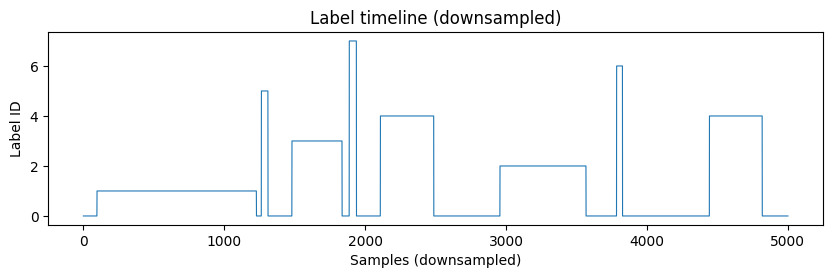

In [11]:
# Quick label timeline (works if labels are per-sample or per-window)
labels = np.array(S.get('label', [])).squeeze()
if labels.size > 0:
    # downsample for quick plotting if needed
    step = max(1, labels.size // 5000)
    plt.figure(figsize=(10,2.5))
    plt.plot(labels[::step], lw=0.8)
    plt.title("Label timeline (downsampled)")
    plt.xlabel("Samples (downsampled)")
    plt.ylabel("Label ID")
    plt.show()


## 2. From ECG to HR and simple HRV (Principles: vagal tone, RSA)

Detected 18567 R-peaks from chest:ECG. RR count=18394
Time-domain HRV: {'SDNN_ms': np.float64(426.8829018876975), 'RMSSD_ms': np.float64(698.4470516017469), 'pNN50_%': np.float64(98.03185994671885)}
Freq-domain HRV: {'LF': np.float64(0.0051875486234314455), 'HF': np.float64(0.04114562090390898), 'LF_HF': np.float64(0.12607778202074985)}


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_21249/3984005132.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], fxx[idx])


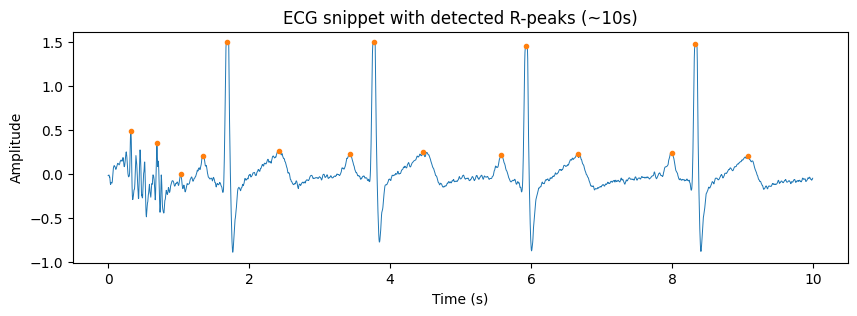

In [12]:
def rr_from_ecg(ecg, fs, min_rr=0.3, max_rr=2.0):
    """Very simple R-peak detection + RR intervals (seconds)."""
    # crude normalization
    x = (ecg - np.median(ecg)) / (np.std(ecg) + 1e-9)
    # find peaks with a refractory period ~min_rr
    peaks, _ = find_peaks(x, distance=int(min_rr*fs), prominence=np.std(x)*0.5)
    rr = np.diff(peaks) / fs  # seconds
    rr = rr[(rr > min_rr) & (rr < max_rr)]
    return peaks, rr

def hrv_time(rr):
    """Basic time-domain HRV: SDNN, RMSSD, pNN50."""
    rr_ms = rr * 1000.0
    sdnn = np.std(rr_ms, ddof=1)
    diff = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff**2))
    pnn50 = np.mean(np.abs(diff) > 50.0) * 100.0
    return {'SDNN_ms': sdnn, 'RMSSD_ms': rmssd, 'pNN50_%': pnn50}

def hrv_freq(rr, fs_interp=4.0):
    """Welch PSD on interpolated tachogram → LF/HF power."""
    # build time axis and interpolate to even sampling
    t = np.cumsum(rr)
    t = t - t[0]
    rr_series = rr
    f = interp1d(t, rr_series, kind='linear', fill_value="extrapolate")
    t_even = np.arange(0, t[-1], 1.0/fs_interp)
    rr_even = f(t_even)
    rr_even = (rr_even - np.mean(rr_even))  # detrend
    fxx, pxx = welch(rr_even, fs=fs_interp, nperseg=min(256, len(rr_even)))
    # integrate bands (Hz): LF 0.04–0.15, HF 0.15–0.40
    def band_power(fb):
        idx = np.logical_and(fxx >= fb[0], fxx < fb[1])
        return np.trapz(pxx[idx], fxx[idx])
    lf = band_power((0.04, 0.15))
    hf = band_power((0.15, 0.40))
    return {'LF': lf, 'HF': hf, 'LF_HF': (lf / hf) if hf > 0 else np.nan}

    # --- pick ECG from chest or BVP from wrist as proxy if ECG missing ---
sig = S.get('signal', {})
ecg = None; fs_ecg = None
  
# Heuristic channel search
for ns in ['chest', 'wrist']:
    if ns in sig:
        for ch in sig[ns]:
            name = ch.lower()
            if 'ecg' in name:
                ecg = np.asarray(sig[ns][ch]).squeeze()
                # If sampling rate metadata not present, set a reasonable guess; or fetch from your dataset readme.
                fs_ecg = 256.0  # TODO: replace with actual fs if known in your copy
                source = f"{ns}:{ch}"
                break
    if ecg is not None:
        break

if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}")
    print("Time-domain HRV:", hrv_time(rr))
    print("Freq-domain HRV:", hrv_freq(rr))
    # Quick visualization
    t_ecg = np.arange(len(ecg))/fs_ecg
    plt.figure(figsize=(10,3))
    plt.plot(t_ecg[:10*int(fs_ecg)], ecg[:10*int(fs_ecg)], lw=0.7)
    pk = peaks[peaks < 10*fs_ecg]
    plt.plot(t_ecg[pk], ecg[pk], 'o', ms=3)
    plt.title("ECG snippet with detected R-peaks (~10s)")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.show()
else:
    print("No ECG channel found. If available, you can use wrist BVP to estimate HR (less ideal for HRV).")

## 4. Basic EDA analysis (Principle: sympathetic arousal)

EDA features (whole recording): {'SCL_median': np.float64(4.696972), 'SCR_rate_per_min': np.float64(11.684964200477326)}


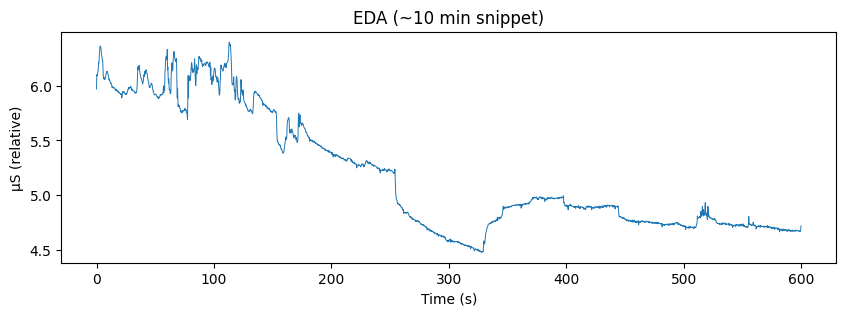

In [13]:
def smooth(x, k=5):
    if k <= 1: return x
    k = int(k)
    pad = (k-1)//2
    xp = np.pad(x, (pad,pad), mode='edge')
    kern = np.ones(k) / k
    return np.convolve(xp, kern, mode='valid')

def eda_basic_features(eda, fs):
    """Very simple tonic/phasic proxies: mean level, # of fast rises per min."""
    eda = np.asarray(eda).astype(float)
    scl = np.median(eda)  # tonic proxy
    # phasic proxy via positive derivative threshold
    d = np.diff(smooth(eda, k=int(fs))) * fs
    thr = np.std(d) * 1.0
    scr_count = np.sum(d > thr) * (60.0 / (len(d)/fs))  # events per minute
    return {'SCL_median': scl, 'SCR_rate_per_min': scr_count}

# Find wrist EDA
eda = None; fs_eda = 4.0  # common Empatica E4 EDA fs; replace with actual if known
if 'wrist' in sig:
    for ch in sig['wrist']:
        if 'eda' in ch.lower():
            eda = np.asarray(sig['wrist'][ch]).squeeze()
            break

if eda is not None:
    feats = eda_basic_features(eda, fs_eda)
    print("EDA features (whole recording):", feats)
    # Quick plot
    n = min(len(eda), int(10*60*fs_eda))
    t = np.arange(n)/fs_eda
    plt.figure(figsize=(10,3))
    plt.plot(t, eda[:n], lw=0.7)
    plt.title("EDA (~10 min snippet)")
    plt.xlabel("Time (s)"); plt.ylabel("μS (relative)")
    plt.show()
else:
    print("No wrist EDA channel found.")


## 4. Respiration & RSA (Principles: vagal brake, cardiorespiratory coupling)

Approx. breaths per minute (first 2 min): 88.23529411764706


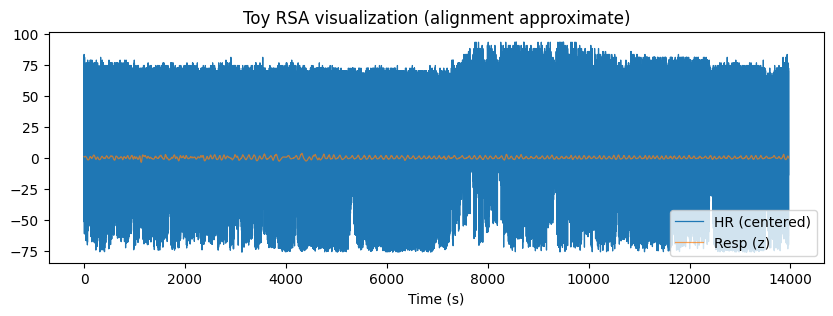

In [14]:
def peak_rate(x, fs, min_interval_s=1.0):
    x = (x - np.median(x)) / (np.std(x)+1e-9)
    peaks, _ = find_peaks(x, distance=int(min_interval_s*fs))
    if len(peaks) < 2:
        return np.nan
    rr = np.diff(peaks)/fs
    return 60.0/np.median(rr)

resp = None; fs_resp = 25.0  # replace with true fs if known
if 'chest' in sig:
    for ch in sig['chest']:
        if 'resp' in ch.lower() or 'breath' in ch.lower():
            resp = np.asarray(sig['chest'][ch]).squeeze()
            break

if resp is not None and ecg is not None:
    brpm = peak_rate(resp[:int(120*fs_resp)], fs_resp, min_interval_s=0.6)
    print("Approx. breaths per minute (first 2 min):", brpm)

    # Toy RSA visualization: plot HR (from RR) vs time and overlay resp
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    t_rr = np.cumsum(rr); t_rr -= t_rr[0]
    hr = 60.0/rr
    # Resample resp to rr timeline (very rough)
    t_resp = np.arange(len(resp))/fs_resp
    f_resp = interp1d(t_resp, (resp - np.mean(resp)), fill_value="extrapolate")
    resp_on_rr = f_resp(np.clip(t_rr, t_resp[0], t_resp[-1]))

    plt.figure(figsize=(10,3))
    plt.plot(t_rr, hr - np.mean(hr), label='HR (centered)', lw=0.9)
    plt.plot(t_rr, resp_on_rr/np.std(resp_on_rr), alpha=0.7, label='Resp (z)', lw=0.9)
    plt.legend(); plt.title("Toy RSA visualization (alignment approximate)")
    plt.xlabel("Time (s)")
    plt.show()
else:
    print("No respiration or ECG available for RSA visualization.")

# 5. Temperature & motion as context (Principle: vasoconstriction & confounds)

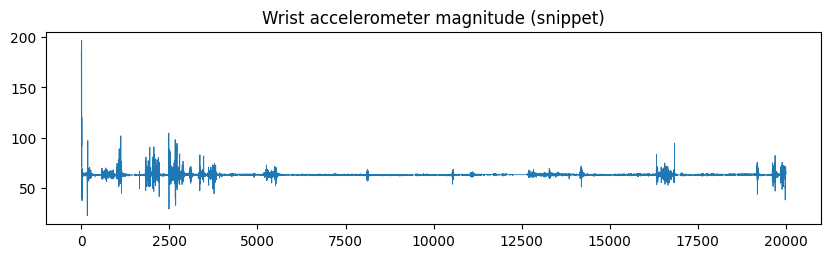

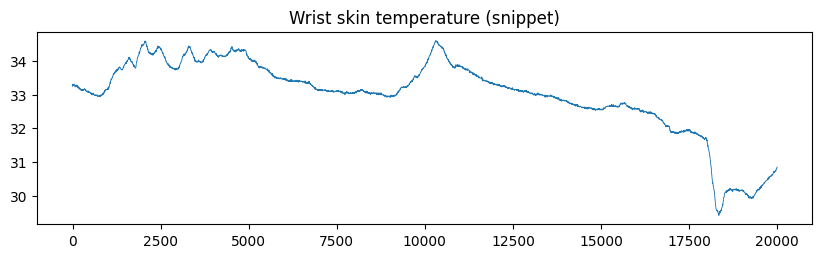

In [15]:
# Wrist temperature & accelerometer magnitude (if present)
temp = None; acc = None
if 'wrist' in sig:
    for ch in sig['wrist']:
        if 'temp' in ch.lower():
            temp = np.asarray(sig['wrist'][ch]).squeeze()
        if 'acc' in ch.lower():
            acc = np.asarray(sig['wrist'][ch])

if acc is not None:
    # handle acc as Nx3 or 3xN
    A = np.asarray(acc)
    if A.ndim == 2 and A.shape[0] == 3:
        A = A.T
    mag = np.linalg.norm(A, axis=1)
    plt.figure(figsize=(10,2.5))
    plt.plot(mag[:20000], lw=0.6)
    plt.title("Wrist accelerometer magnitude (snippet)")
    plt.show()

if temp is not None:
    n = min(len(temp), 20000)
    plt.figure(figsize=(10,2.5))
    plt.plot(temp[:n], lw=0.6)
    plt.title("Wrist skin temperature (snippet)")
    plt.show()

## 6. State-wise comparisons (Principle: link signals ↔ states)

In [17]:
def windowed(arr, idx_mask):
    if arr is None or idx_mask.sum()==0:
        return None
    return arr[idx_mask]

# TODO: Replace these with true masks from your label map
mask_baseline = np.zeros_like(labels, dtype=bool)
mask_stress   = np.zeros_like(labels, dtype=bool)
mask_amuse    = np.zeros_like(labels, dtype=bool)

# Example: if your labels use 1=baseline,2=stress,3=amusement (confirm in YOUR copy!)
# mask_baseline = labels==1; mask_stress = labels==2; mask_amuse = labels==3

# HRV comparison (requires mapping RR samples back to label domain—approximate with peak times)
def rr_masked_stats(ecg, fs_ecg, label_mask):
    if ecg is None or fs_ecg is None or label_mask is None:
        return None
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    t_peaks = peaks / fs_ecg
    # Convert label_mask (per-sample) into a mask over RR intervals by midpoint time
    midtimes = (t_peaks[1:] + t_peaks[:-1])/2
    # Build boolean mask by indexing label array at nearest sample
    idx = np.clip((midtimes * fs_ecg).astype(int), 0, len(label_mask)-1)
    keep = label_mask[idx]
    rr_sel = rr[keep]
    if len(rr_sel) < 10:
        return None
    return {**hrv_time(rr_sel), **hrv_freq(rr_sel)}

stats_baseline = rr_masked_stats(ecg, fs_ecg, mask_baseline)
stats_stress   = rr_masked_stats(ecg, fs_ecg, mask_stress)
stats_amuse    = rr_masked_stats(ecg, fs_ecg, mask_amuse)
print("Baseline HRV:", stats_baseline)
print("Stress   HRV:", stats_stress)
print("Amuse.   HRV:", stats_amuse)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 18394 but size of corresponding boolean axis is 18566